# Synthesizing a whole table with `LanguageModelSynthesizer`

The four supervised estimators each fix which columns of the shared fine-tune (`00-intro.ipynb`) go
in the prompt. Drop that constraint and you get a generator of whole rows: `LanguageModelSynthesizer`
is a thin facade over the same `TabularLanguageModel` that fits on a table with no fixed target and
samples entire rows from the learned joint distribution $p(x_1,\dots,x_d)$.

By the autoregressive factorization, a row is generated one column at a time — the first from its marginal, each next
conditioned on the cells already produced:

$$ p(x_1,\dots,x_d) = p\!\left(x_{\pi(1)}\right)\prod_{k=2}^{d} p\!\left(x_{\pi(k)} \mid x_{\pi(1)},\dots,x_{\pi(k-1)}\right). $$

Because training permuted the order $\pi$, the model can start from *any* column. Here we make
sampling **class-balanced** by conditioning on the species and letting the model fill the four
measurements — each row is then a draw from $p(\text{features} \mid \text{species})$. We then check
the synthetic table against real Iris on three axes: per-feature moments, class structure in feature
space, and label balance.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

from sklm import (
    GenerationConfig,
    JSONSerializer,
    JupyterCallback,
    LanguageModelSynthesizer,
    LRScheduler,
    SpacedDigits,
    TrainingConfig,
)

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
N_SYNTH = 150

## Data: the full Iris table (features + species)

In [2]:
iris = load_iris(as_frame=True)
numeric = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
real = iris.data.set_axis(numeric, axis=1).round(1)
real["species"] = iris.target_names[iris.target]
real.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Fine-tuning

We fit on the whole table with no fixed target — thanks to order permutation, every column is a
target at some point. `SpacedDigits` emits one token per digit, which helps the small model handle
the numeric columns.

In [3]:
synthesizer = LanguageModelSynthesizer(
    backend="mlx",
    model="mlx-community/distilgpt2",
    serializer=JSONSerializer(number=SpacedDigits()),
    training=TrainingConfig(
        epochs=7,
        batch_size=8,
        augmentation_factor=12,
        lr_scheduler=LRScheduler.linear(learning_rate=1e-4),
    ),
    callback=JupyterCallback(),
    random_state=SEED,
).fit(real)

## Conditional sampling per species

For each species we request `N_SYNTH / 3` rows and let the model generate the four measurements. A
sequence of `condition` mappings gives one fixed-column spec per row and overrides `n_samples`.
`sample` retries malformed rows internally and raises if any stays broken after the retries — so the
returned table is always complete, no `None` filtering needed. Sampling with `temperature > 0` is
what gives the rows their diversity — greedy decoding would collapse every row to the same mode.

In [4]:
labels = list(iris.target_names)
per_class = N_SYNTH // len(labels)
condition = [{"species": label} for label in labels for _ in range(per_class)]

synth = synthesizer.sample(condition=condition, generation=GenerationConfig(temperature=1.2))
print(f"synthetic rows: {len(synth)}")
synth.head()

synthetic rows: 150


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.0,4.2,1.2,0.2,setosa
1,5.6,3.3,1.5,0.2,setosa
2,5.1,3.0,1.5,0.2,setosa
3,5.2,3.0,1.5,0.2,setosa
4,4.8,3.0,1.6,0.2,setosa


## Per-feature moments: real vs. synthetic

If the conditional was recovered, the synthetic mean and standard deviation should track the
real column's.

In [5]:
comparison = pd.DataFrame(
    {
        "real_mean": real[numeric].mean(),
        "synth_mean": synth[numeric].mean(),
        "real_std": real[numeric].std(),
        "synth_std": synth[numeric].std(),
    }
).round(2)
comparison

,real_mean,synth_mean,real_std,synth_std
sepal_length,5.84,5.82,0.83,0.89
sepal_width,3.06,3.05,0.44,0.47
petal_length,3.76,3.81,1.77,1.83
petal_width,1.20,1.19,0.76,0.75


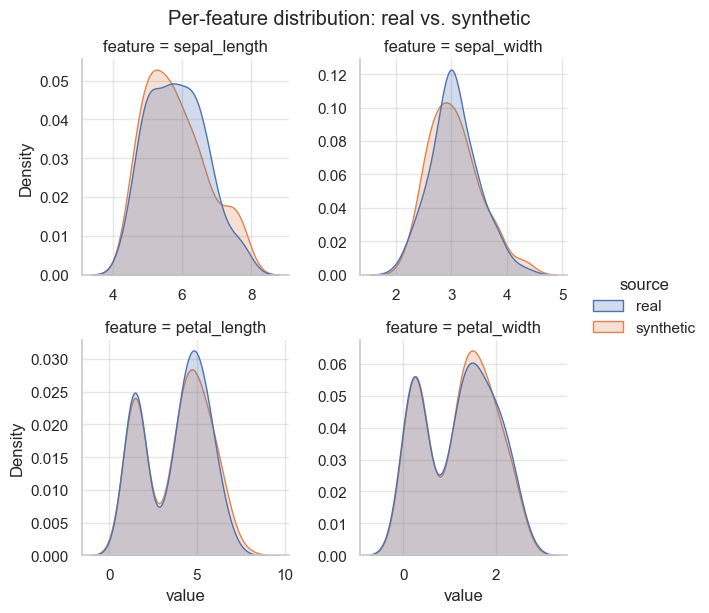

In [6]:
long = pd.concat(
    [real.assign(source="real"), synth.assign(source="synthetic")], ignore_index=True
)
melted = long.melt(
    id_vars=["species", "source"], value_vars=numeric,
    var_name="feature", value_name="value",
)

g = sns.displot(
    melted, x="value", hue="source", col="feature", kind="kde", fill=True,
    col_wrap=2, height=3, facet_kws={"sharex": False, "sharey": False},
)
g.figure.suptitle("Per-feature distribution: real vs. synthetic", y=1.02)
plt.show()

## Class structure

If the joint was recovered, the three synthetic species should separate in petal space just like
real Iris does.

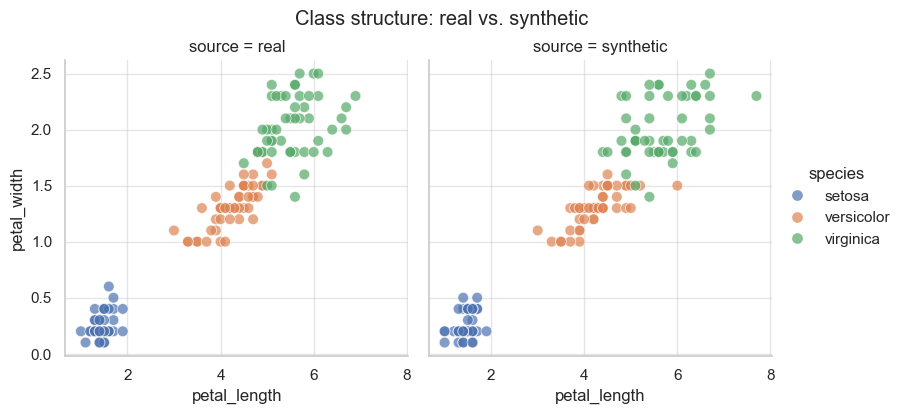

In [7]:
g = sns.relplot(
    long, x="petal_length", y="petal_width", hue="species", col="source",
    s=60, alpha=0.7, height=4,
)
g.figure.suptitle("Class structure: real vs. synthetic", y=1.03)
plt.show()

## Class balance

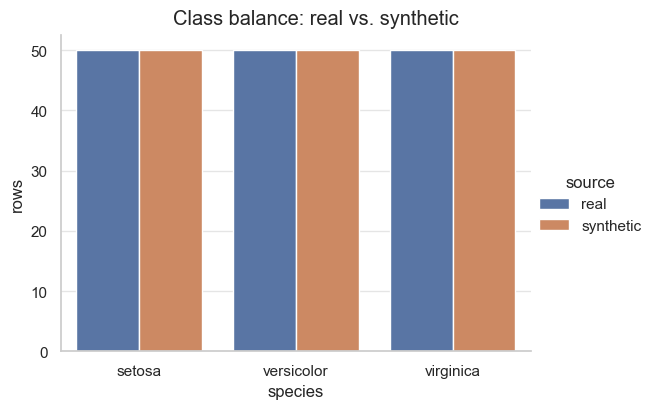

In [8]:
balance = (
    pd.DataFrame(
        {
            "real": real["species"].value_counts(),
            "synthetic": synth["species"].value_counts(),
        }
    )
    .reset_index(names="species")
    .melt(id_vars="species", var_name="source", value_name="n")
)

g = sns.catplot(balance, kind="bar", x="species", y="n", hue="source", height=4, aspect=1.4)
g.set_axis_labels("species", "rows")
g.figure.suptitle("Class balance: real vs. synthetic", y=1.02)
plt.show()